In [1]:
from itertools import groupby

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


#### Carregamento dos dados

In [2]:
df = pd.read_json('dados.txt')
df.head()

,Film,Year,Genre,Worldwide_Gross_M,Budget_M
0,Harry Potter and the Deathly Hallows Part 2,2011,Fantasy,1328,125
1,Mission Impossible 4,2011,Action,689,145
2,Toy Story 3,2010,Animation,1063,200
3,2012,2009,Action,768,200
4,Alice in Wonderland,2010,Adventure,1024,200


#### Visualização Orçamento dos Filmes

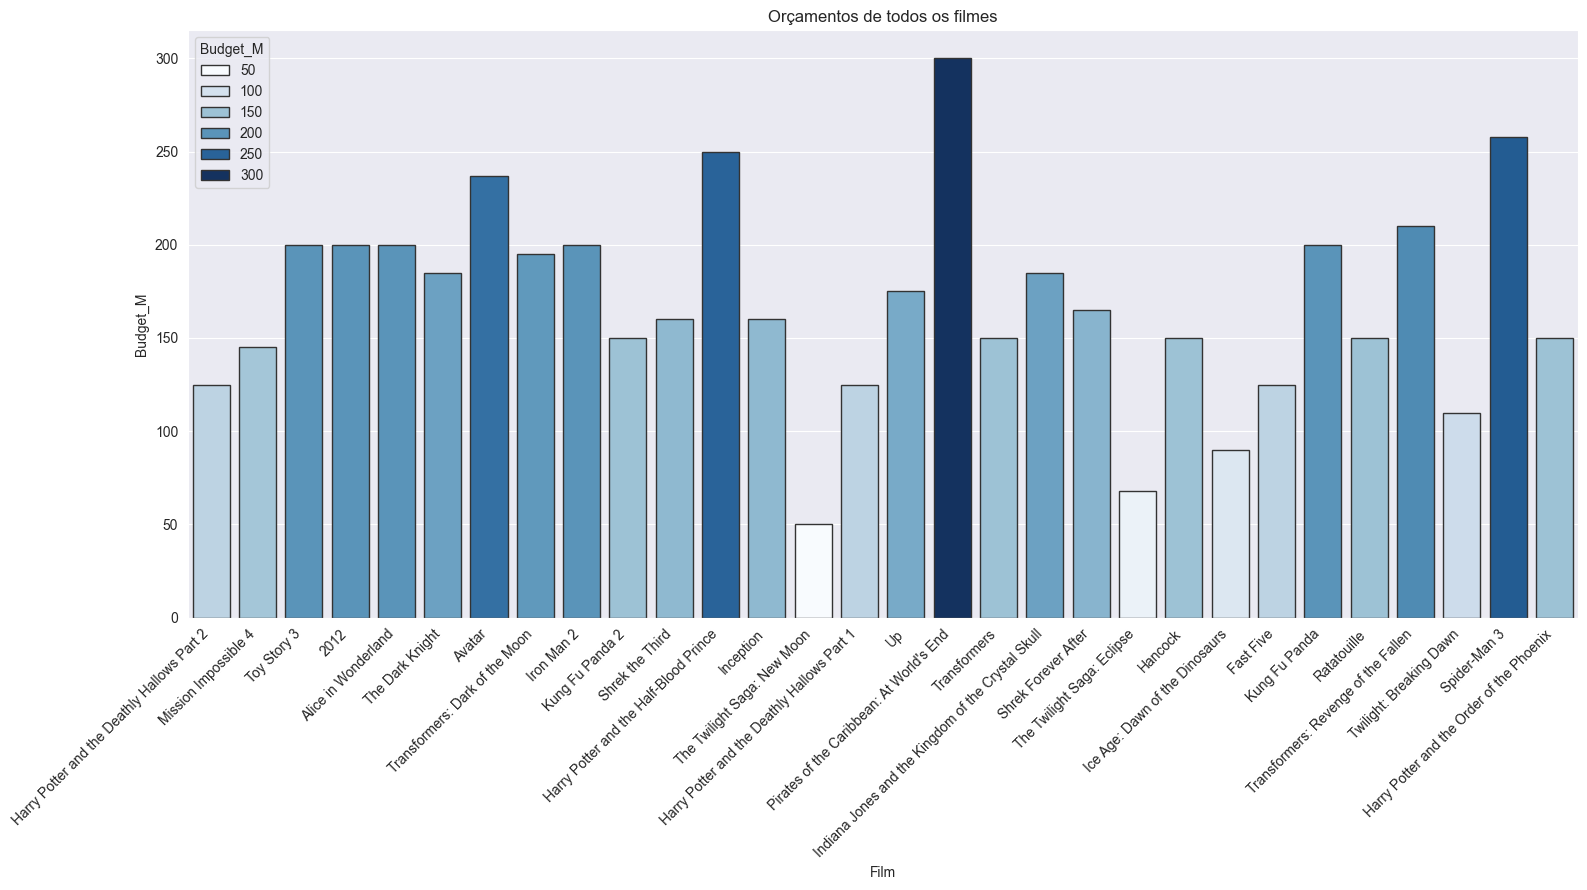

In [21]:
plt.figure(figsize=(16,9))
plt.title("Orçamentos de todos os filmes")
sns.barplot(x='Film', y='Budget_M', errorbar=None, palette='Blues', hue='Budget_M', edgecolor='0.2', data=df)

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Filme com maior e menor orçamento

In [32]:
maior_orc = df.iloc[df['Budget_M'].idxmax()]['Film']
#ou
#df.iloc[df['Budget_M'].idxmax()].values[0]
print("O filme com maior orçamento é", maior_orc)

O filme com maior orçamento é Pirates of the Caribbean: At World's End


In [35]:
menor_orc = df.iloc[df['Budget_M'].idxmin()]['Film']
print("O filme com menor orçamento é", menor_orc)

O filme com menor orçamento é The Twilight Saga: New Moon


#### Bilheteria

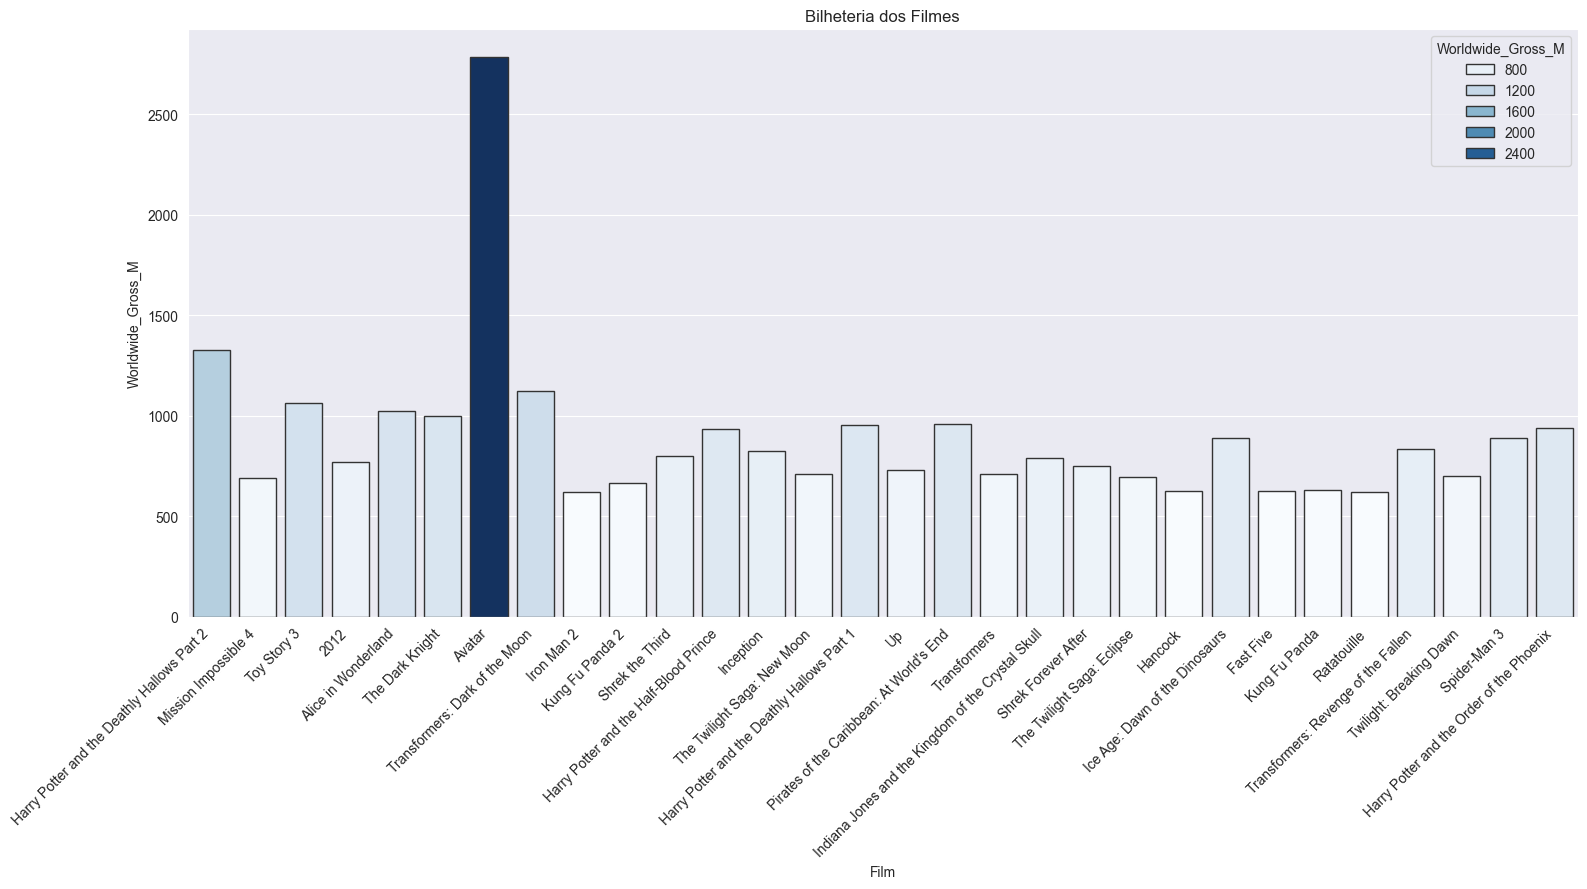

In [12]:
plt.figure(figsize=(16,9))
plt.title("Bilheteria dos Filmes")
sns.barplot(x='Film', y='Worldwide_Gross_M', data=df, palette='Blues', hue='Worldwide_Gross_M', edgecolor='0.2')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
maior_bil = df.sort_values(by='Worldwide_Gross_M', ascending=False).iloc[0]['Film']
print("O filme com maior bilheteria foi", maior_bil)

O filme com maior bilheteria foi Avatar


In [20]:
menor_bil = df.sort_values(by='Worldwide_Gross_M', ascending=True).iloc[0]['Film']
print("O filme com menor bilheteria foi", menor_bil)

O filme com menor bilheteria foi Ratatouille


#### Quantidade de filmes por gênero em cada ano.
#### Em que ano foram feitos menos filmes de ação.
#### Em que ano foram feitos menos filmes de aventura.

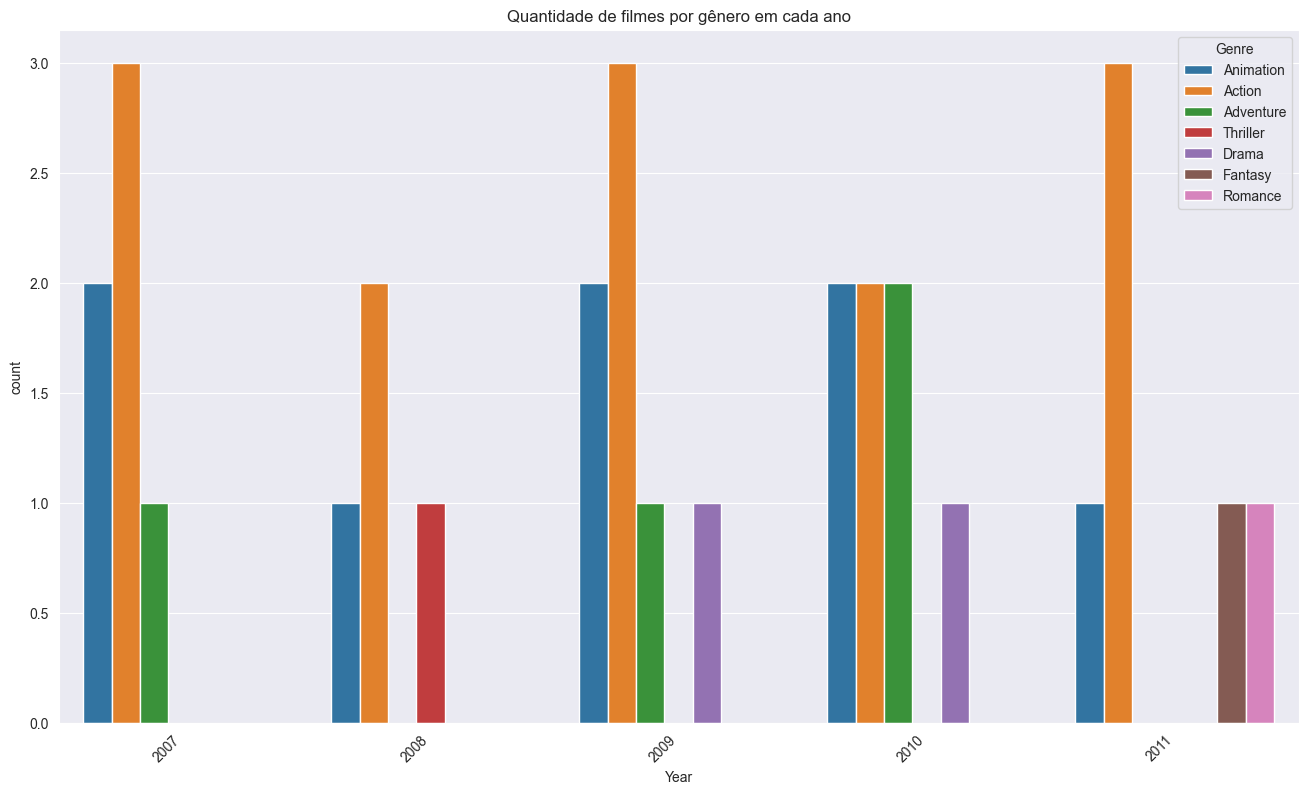

In [26]:
plt.figure(figsize=(16,9))
plt.title("Quantidade de filmes por gênero em cada ano")
sns.countplot(x='Year', hue='Genre', data=df)
plt.xticks(rotation=45, ha='right')
plt.show()

In [44]:
cont_acao_ano = df[df['Genre'] == 'Action'].groupby('Year').count()
menor_qtde = cont_acao_ano.sort_values(by='Film', ascending=True).iloc[0]['Film']

In [76]:
anos_menos_filme_acao = cont_acao_ano[cont_acao_ano['Film'] == menor_qtde].index.values

In [75]:
anos = list(map(str, anos_menos_filme_acao))

In [79]:
if len(anos_menos_filme_acao) > 1:
    print("Foram feitos menos filmes de ação nos anos", str(", ").join(anos) )
else:
    print("Fora feitos menos filmes de ação no ano", *ano)

Foram feitos menos filmes de ação nos anos 2008, 2010


In [91]:
film_avent_ano = df[df['Genre'] == 'Animation'].groupby('Year').count()
menor_qtde_avent = film_avent_ano.sort_values(by='Film', ascending=True).iloc[0]['Film']

In [92]:
anos_avent = film_avent_ano[film_avent_ano['Film'] == menor_qtde_avent].index.values
anos = list(map(str, anos_avent))

In [93]:
if(len(anos_avent) > 1):
    print("Foram feitos menos filmes de aventura nos anos", str(", ").join(anos) )
else:
    print("Foram feitos menos filmes de aventura no ano", *anos)

Foram feitos menos filmes de aventura nos anos 2008, 2011


#### Média de Orçamento por Gênero nos Anos
#### Em que ano os filmes de ação tiveram maior média de orçamento
#### Em que ano os filmes de animação tiveram maior média de orçamento

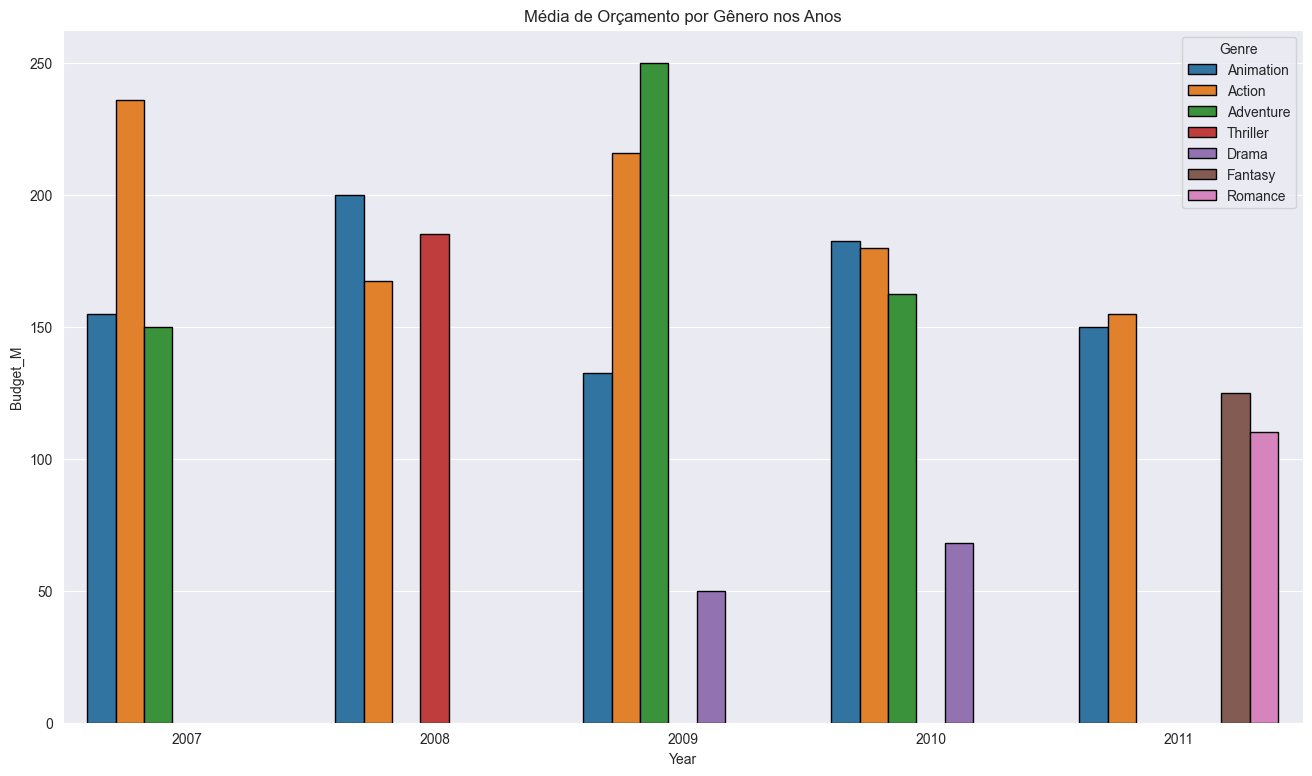

In [11]:
plt.figure(figsize=(16,9))
plt.title("Média de Orçamento por Gênero nos Anos")
sns.barplot(x='Year', y='Budget_M', hue='Genre', data=df, palette='tab10', edgecolor='0.0', errorbar=None)
plt.show()

In [13]:
filmes_acao = df[df['Genre'] == 'Action']

In [28]:
medias_orcamento_acao = filmes_acao.groupby(['Year']).mean(['Budget_M']).drop(['Worldwide_Gross_M'], axis=1)

In [50]:
medias_orcamento_acao = medias_orcamento_acao.sort_values(by='Budget_M', ascending=False).iloc[0]

In [53]:
print("O ano com maior média de orçamento nos filmes de ação foi em", medias_orcamento_acao.name, " com o orçamento de", int(medias_orcamento_acao.values[0]), "Milhões")

O ano com maior média de orçamento nos filmes de ação foi em 2007  com o orçamento de 236 Milhões


In [54]:
filmes_animacao = df[df['Genre'] == 'Animation']

In [60]:
valores_animacao = filmes_animacao.groupby(['Year']).mean(['Budget_M']).drop('Worldwide_Gross_M', axis=1).sort_values(by='Budget_M', ascending=False).iloc[0]

In [61]:
ano_maior_media_orc_animacao = valores_animacao.name

In [63]:
valor_maior_media_orc_animacao = int(valores_animacao.values[0])

In [66]:
print("O ano com a maior média de orçamento de filmes de animação foi", ano_maior_media_orc_animacao, "e o valor foi de", valor_maior_media_orc_animacao, "Milhões")

O ano com a maior média de orçamento de filmes de animação foi 2008 e o valor foi de 200 Milhões
